In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
# mplsoccer 의 statsbomb 모듈 
from mplsoccer import Sbopen, Pitch

# 타원 시각화 모듈
from matplotlib.patches import Ellipse
import numpy as np

from matplotlib.patches import Wedge

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False


# parser 객체를 인스턴스화
parser = Sbopen()

df_competition = parser.competition()
# df_competition.info()

# df_competition FIFA WORLD CUP의 이름과 ID를 파악하고 df_worldcup 

# df_competition[["competition_id","season_id","competition_name","season_name"]].head(60)

df_worldcup = df_competition[df_competition['competition_name'] == 'FIFA World Cup']
df_worldcup[["competition_id","season_id","competition_name","season_name"]].head(60)


,competition_id,season_id,competition_name,season_name
30,43,106,FIFA World Cup,2022
31,43,3,FIFA World Cup,2018
32,43,55,FIFA World Cup,1990
33,43,54,FIFA World Cup,1986
34,43,51,FIFA World Cup,1974
35,43,272,FIFA World Cup,1970
36,43,270,FIFA World Cup,1962
37,43,269,FIFA World Cup,1958


In [3]:
# 대한민국 경기 목록만 찾아오기
df_matches = parser.match(competition_id=43, season_id=106)
df_matches[['home_team_id','home_team_name','away_team_id','away_team_name']].head(40) # 이렇게 해서 대한민국의 id 와 name 형식을 파악

# 조건식 구조
df_kor_matches = df_matches[(df_matches['home_team_name'] == 'South Korea') | (df_matches['away_team_name'] == 'South Korea')]

# 대한민국 경기만 나오도록 설정
df_kor_matches[['match_id','home_team_id','home_team_name','away_team_id','away_team_name']]

,match_id,home_team_id,home_team_name,away_team_id,away_team_name
35,3857287,783,Uruguay,791,South Korea
48,3869253,781,Brazil,791,South Korea
57,3857299,791,South Korea,4885,Ghana
63,3857262,791,South Korea,780,Portugal


In [4]:
# 경기 이벤트 데이터 불러오기
df_event, df_realted, df_freeze, df_tactics = parser.event(3857287)

# 대한민국 데이터만 필터링 (대괄로 감싸는건 필수)
df_kor_event = df_event[df_event['team_name'] == 'South Korea']

# 우루과이 데이터만 필터링 
df_ur_event = df_event[df_event['team_name'] == 'Uruguay']
# 이벤트 개수 확인
print(len(df_kor_event))
print(len(df_ur_event))

1578
1884


In [5]:
# 교체 발생 필터링
kor_sub_events = df_kor_event[df_kor_event['type_name'] == 'Substitution']
ur_sub_events = df_ur_event[df_ur_event['type_name'] == "Substitution"]

# 첫 교체 시간 구하기
first_kor_sub_min = kor_sub_events.iloc[0]['minute']
first_ur_sub_min = ur_sub_events.iloc[0]['minute']

print(f"대한민국 첫 교체 시간: {first_kor_sub_min}분")
print(f"우루과이 첫 교체 시간: {first_ur_sub_min}분")


대한민국 첫 교체 시간: 73분
우루과이 첫 교체 시간: 63분


In [6]:
kor_passes = df_kor_event[
    (df_kor_event['minute'] < first_kor_sub_min) &
    (df_kor_event['type_name'] == 'Pass') &
    (df_kor_event['outcome_name'].isna())
]
ur_passes = df_ur_event[
    (df_ur_event['minute'] < first_ur_sub_min) &
    (df_ur_event['type_name'] == 'Pass') &
    (df_ur_event['outcome_name'].isna())
]


In [7]:
# 대한민국 선수별 평균 좌표 계산하기
kor_player_coords = kor_passes.groupby('player_name')[['x', 'y']].mean().reset_index()
# 우루과이 선수별 평균 좌표 계산하기
ur_player_coords = ur_passes.groupby('player_name')[['x', 'y']].mean().reset_index() 

print(f'대한민국 선발 인원수: {len(kor_player_coords)}명')
print(f'우루과이 선발 인원수: {len(ur_player_coords)}명')

대한민국 선발 인원수: 11명
우루과이 선발 인원수: 11명


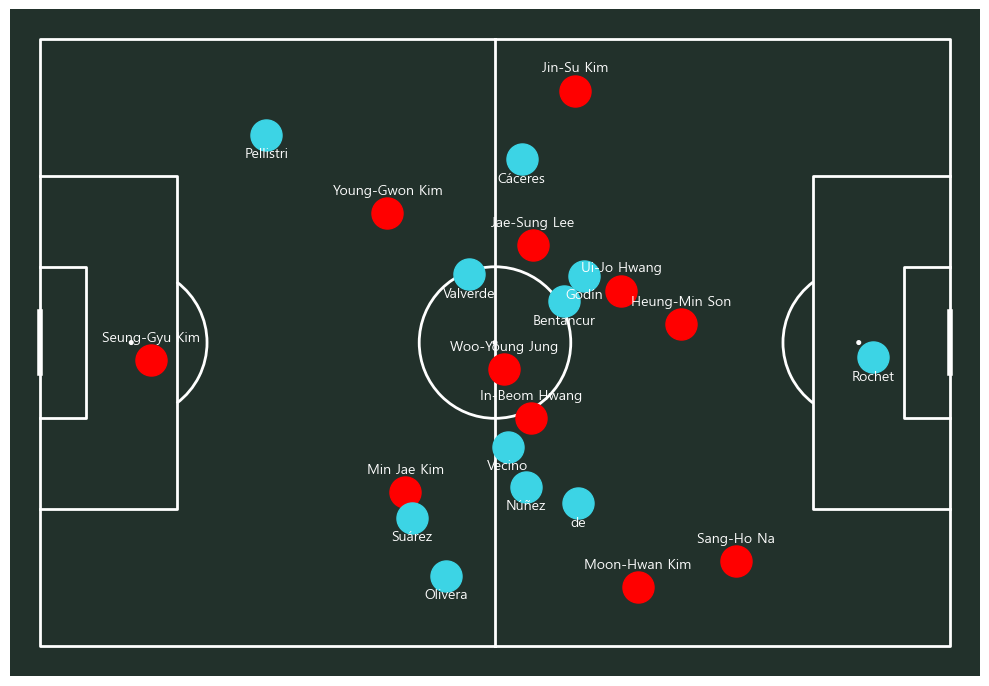

In [8]:
pitch = Pitch(pitch_type='statsbomb' , pitch_color='#22312b', line_color='white')
fig, ax = pitch.draw(figsize=(10,7))

# 1. 대한민국 (붉은 점 찍기)
pitch.scatter(
    kor_player_coords['x'], 
    kor_player_coords['y'], 
    s=500, 
    color='red', 
    ax=ax
    )

# 1-1. 우루과이 (하늘색 점 찍기)
pitch.scatter(
    120-ur_player_coords['x'], 
    80-ur_player_coords['y'], 
    s=500, 
    color='#3cd4e5', 
    ax=ax
    )

# 2. 대한민국 선수 이름 표시 (반복문으로 채우기)
for idx, row in kor_player_coords.iterrows():
    pitch.annotate(
        text=row['player_name'],
        xy=(row['x'], row['y'] - 2.5),
        c='white', ha='center', ax= ax
    )
# 2-1. 우루과이 선수 이름 표시 
for idx, row in ur_player_coords.iterrows():
    pitch.annotate(
        text=row['player_name'].split()[-2],
        xy=(120-row['x'], 80-row['y'] + 3),
        c='white', ha='center', ax= ax
    )    

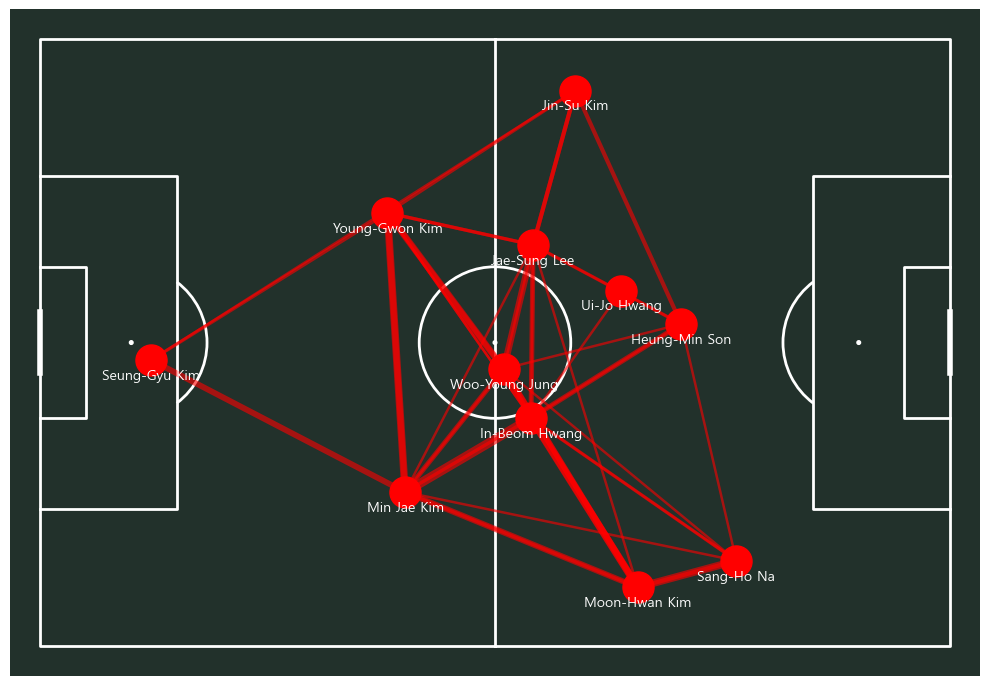

In [9]:
pitch = Pitch(pitch_type='statsbomb' , pitch_color='#22312b', line_color='white')
fig, ax = pitch.draw(figsize=(10,7))

# 선수들간의 패스 횟수
kor_passes_between = kor_passes.groupby(['player_name', 'pass_recipient_name']).size().reset_index(name='pass_count')

# 패스 횟수를 1 ~ 2회 정도로 하면 선이 너무 많아져서 지저분해질수 있기때문에 4회 정도로 설정
kor_passes_between = kor_passes_between[kor_passes_between['pass_count'] > 2]

# 패스 횟수 표에 선수들의 평균 좌표(x,y) 합치기
# 1. 패스 보낸 사람(player_name)의 평균 x,y 좌표 붙이기
kor_passes_between = kor_passes_between.merge(kor_player_coords, on='player_name')

# 2. 패스 받은 사람 (pass_recipient_name)의 평균 x,y 좌표 붙이기
# (이때 x, y 컬럼명이 겹치므로 각각 x_end, y_end 같은 이름으로 들어감)
kor_passes_between = kor_passes_between.merge(kor_player_coords, left_on='pass_recipient_name', right_on='player_name', suffixes=('', '_end'))


# 1. 대한민국 (붉은 점 찍기)
pitch.scatter(
    kor_player_coords['x'], 
    kor_player_coords['y'], 
    s=500, 
    color='red', 
    ax=ax
)
# 2. 대한민국 선수 이름 표시 (반복문으로 채우기)
for idx, row in kor_player_coords.iterrows():
    pitch.annotate(
        text=row['player_name'],
        xy=(row['x'], row['y'] + 2.5),
        c='white', ha='center', ax= ax
)
# 3. 대한민국 패스 연결선
pitch.lines(
    kor_passes_between['x'], kor_passes_between['y'], # 시작점 (패스 보낸 사람 좌표)
    kor_passes_between['x_end'], kor_passes_between['y_end'], # 끝점 (패스 받은 사람 좌표)
    linewidth=kor_passes_between['pass_count'] * 0.6,         # 패스 횟수에 비례해서 선 두께 조절
    color='red',
    alpha=0.6,                                                  # 선 투명도
    ax=ax

)    


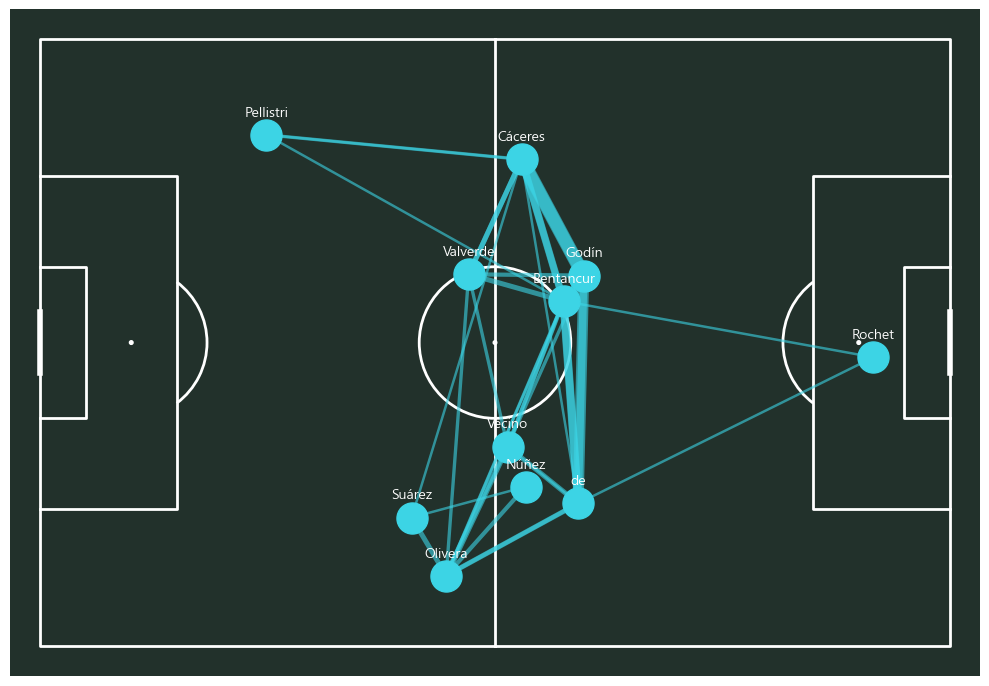

In [10]:
pitch = Pitch(pitch_type='statsbomb' , pitch_color='#22312b', line_color='white')
fig, ax = pitch.draw(figsize=(10,7))

# 우루과이 패스맵
ur_passes_between = ur_passes.groupby(['player_name', 'pass_recipient_name']).size().reset_index(name='pass_count')

ur_passes_between = ur_passes_between[ur_passes_between['pass_count'] > 2]

ur_passes_between = ur_passes_between.merge(ur_player_coords, on='player_name')

ur_passes_between = ur_passes_between.merge(ur_player_coords, left_on='pass_recipient_name', right_on='player_name', suffixes=('', '_end'))


# 1. 우루과이 (하늘색 점 찍기)
pitch.scatter(
    120-ur_player_coords['x'], 
    80-ur_player_coords['y'], 
    s=500, 
    color='#3cd4e5', 
    ax=ax
)
# 2. 우루과이 선수 이름 표시 
for idx, row in ur_player_coords.iterrows():
    pitch.annotate(
        text=row['player_name'].split()[-2],
        xy=(120-row['x'], 80-row['y'] - 2.5),
        c='white', ha='center', ax= ax
)
# 3. 우루과이 패스 연결선
pitch.lines(
    120-(ur_passes_between['x']), 80-ur_passes_between['y'], #오른쪽에 나타내기위해선 120에서 빼줘야한다.
    120-(ur_passes_between['x_end']), 80-ur_passes_between['y_end'], 
    linewidth=ur_passes_between['pass_count'] * 0.6,         
    color='#3cd4e5',
    alpha=0.6,                                                  
    ax=ax

)    

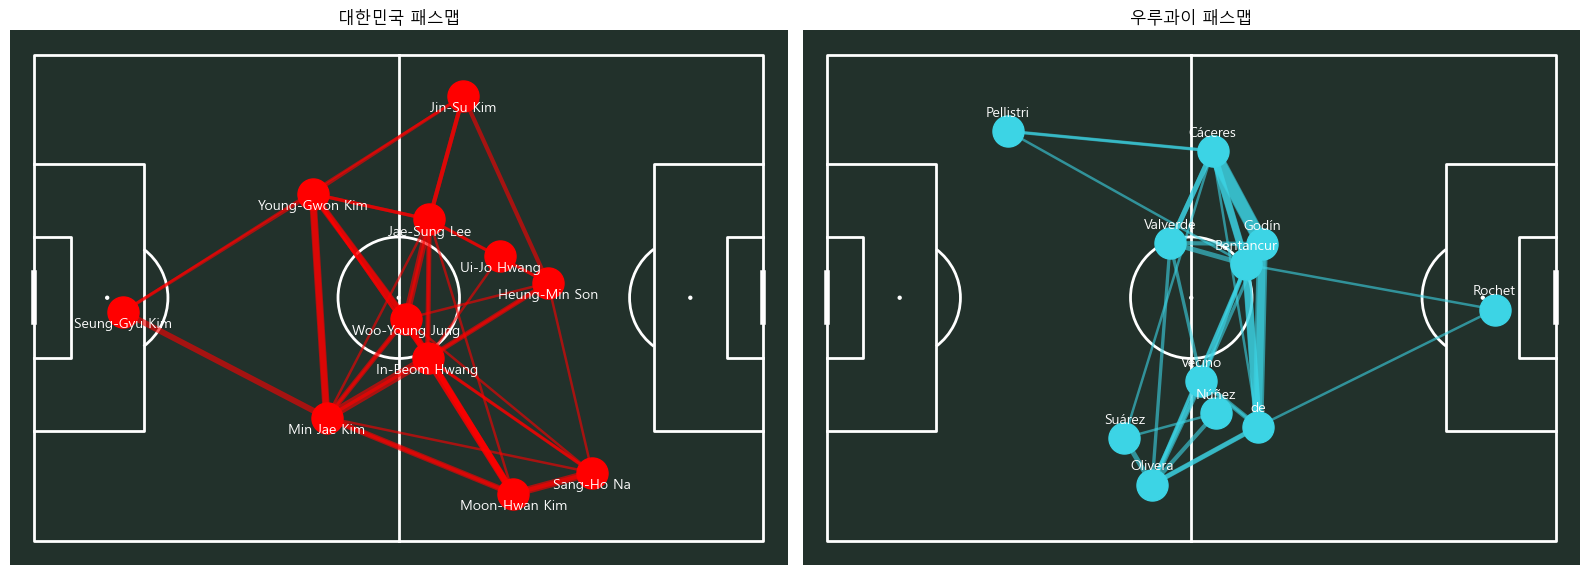

In [11]:
pitch = Pitch(pitch_type='statsbomb' , pitch_color='#22312b', line_color='white')

fig, (ax1, ax2) = pitch.draw(nrows=1, ncols=2, figsize=(16,8))
ax1.set_title('대한민국 패스맵')
ax2.set_title('우루과이 패스맵')

# 선수들간의 패스 횟수
kor_passes_between = kor_passes.groupby(['player_name', 'pass_recipient_name']).size().reset_index(name='pass_count')
ur_passes_between = ur_passes.groupby(['player_name', 'pass_recipient_name']).size().reset_index(name='pass_count')
# 패스 횟수를 1 ~ 2회 정도로 하면 선이 너무 많아져서 지저분해질수 있기때문에 3회 정도로 설정
kor_passes_between = kor_passes_between[kor_passes_between['pass_count'] > 2]
ur_passes_between = ur_passes_between[ur_passes_between['pass_count'] > 2]
# 패스 횟수 표에 선수들의 평균 좌표(x,y) 합치기
# 1. 패스 보낸 사람(player_name)의 평균 x,y 좌표 붙이기
kor_passes_between = kor_passes_between.merge(kor_player_coords, on='player_name')
ur_passes_between = ur_passes_between.merge(ur_player_coords, on='player_name')
# 2. 패스 받은 사람 (pass_recipient_name)의 평균 x,y 좌표 붙이기
# (이때 x, y 컬럼명이 겹치므로 각각 x_end, y_end 같은 이름으로 들어감)
kor_passes_between = kor_passes_between.merge(kor_player_coords, left_on='pass_recipient_name', right_on='player_name', suffixes=('', '_end'))
ur_passes_between = ur_passes_between.merge(ur_player_coords, left_on='pass_recipient_name', right_on='player_name', suffixes=('', '_end'))


# 1. 대한민국 (붉은 점 찍기)
pitch.scatter(
    kor_player_coords['x'], 
    kor_player_coords['y'], 
    s=500, 
    color='red', 
    ax=ax1
)
# 2. 대한민국 선수 이름 표시 (반복문으로 채우기)
for idx, row in kor_player_coords.iterrows():
    pitch.annotate(
        text=row['player_name'],
        xy=(row['x'], row['y'] + 2.5),
        c='white', ha='center', ax= ax1
)
# 3. 대한민국 패스 연결선
pitch.lines(
    kor_passes_between['x'], kor_passes_between['y'], # 시작점 (패스 보낸 사람 좌표)
    kor_passes_between['x_end'], kor_passes_between['y_end'], # 끝점 (패스 받은 사람 좌표)
    linewidth=kor_passes_between['pass_count'] * 0.6,         # 패스 횟수에 비례해서 선 두께 조절
    color='red',
    alpha=0.6,                                                  # 선 투명도
    ax=ax1

) 

# 1. 우루과이 (하늘색 점 찍기)
pitch.scatter(
    120-ur_player_coords['x'], 
    80-ur_player_coords['y'], 
    s=500, 
    color='#3cd4e5', 
    ax=ax2
)
# 2. 우루과이 선수 이름 표시 
for idx, row in ur_player_coords.iterrows():
    pitch.annotate(
        text=row['player_name'].split()[-2],
        xy=(120-row['x'], 80-row['y'] - 2.5),
        c='white', ha='center', ax= ax2
)
# 3. 우루과이 패스 연결선
pitch.lines(
    120-(ur_passes_between['x']), 80-ur_passes_between['y'], #오른쪽에 나타내기위해선 120에서 빼줘야한다.
    120-(ur_passes_between['x_end']), 80-ur_passes_between['y_end'], 
    linewidth=ur_passes_between['pass_count'] * 0.6,         
    color='#3cd4e5',
    alpha=0.6,                                                  
    ax=ax2
)


329


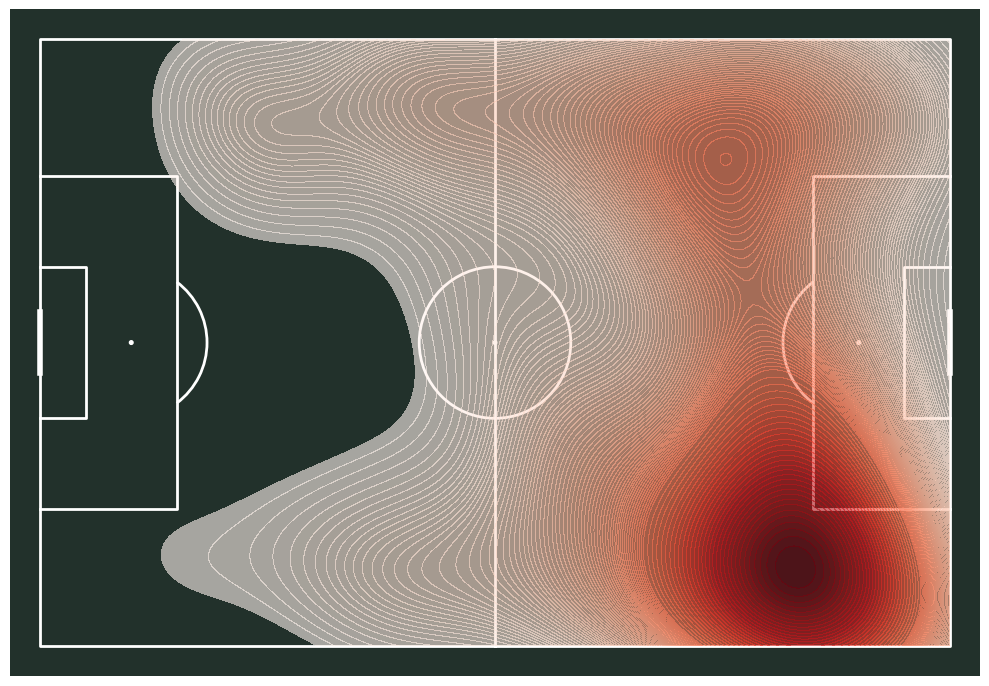

In [12]:
pitch = Pitch(pitch_type='statsbomb' , pitch_color='#22312b', line_color='white')
fig, ax = pitch.draw(figsize=(10,7))

# 대한민국 전체 이벤트 중 3톱 선수의 이벤트만 추출
kor_roots_events = df_kor_event[
    df_kor_event['player_name'].isin(['Sang-Ho Na', 'Heung-Min Son', 'Ui-Jo Hwang'])
].dropna(subset=['x','y']) # 좌표값이 없는 데이터는 제거

# 3톱의 밀도 히트맵 그리기
pitch.kdeplot(
    kor_roots_events['x'],
    kor_roots_events['y'],
    ax=ax,
    fill=True,      # 밀도 영역 내부 채우기
    levels=100,     # 밀도 세밀도 (숫자가 클수록 등선이 부드러움)
    cmap='Reds',     
    alpha=0.6       # 경기장 라인이 비치도록 반투명도
)

# 데이터 개수 확인
print(len(kor_roots_events))


275


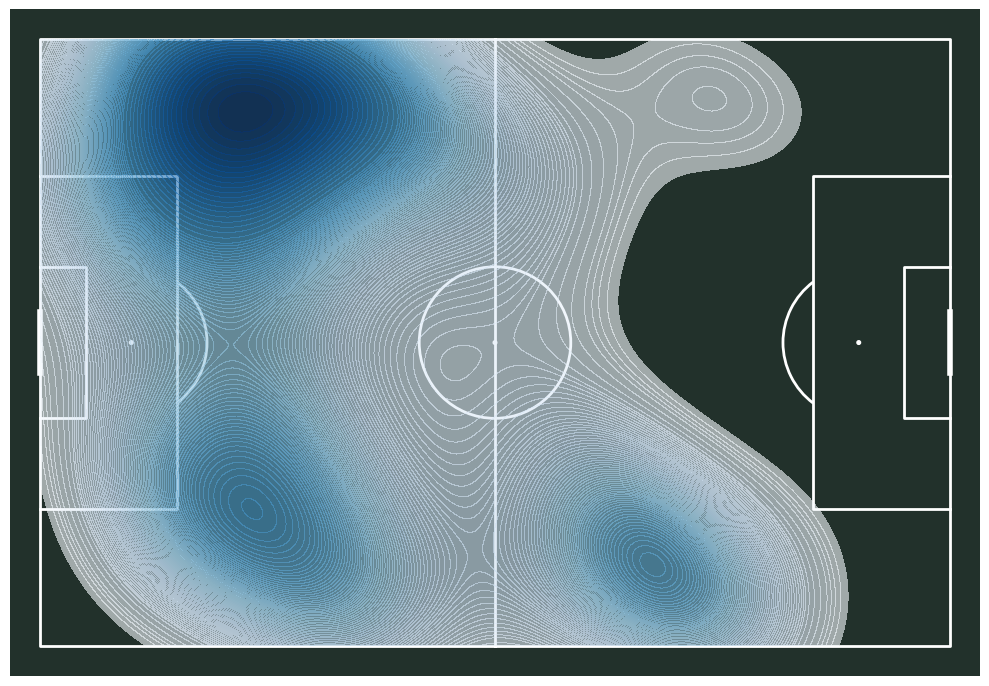

In [13]:
pitch = Pitch(pitch_type='statsbomb' , pitch_color='#22312b', line_color='white')
fig, ax = pitch.draw(figsize=(10,7))

ur_roots_events = df_ur_event[
    df_ur_event['player_name'].isin(['Darwin Gabriel Núñez Ribeiro', 'Luis Alberto Suárez Díaz','Facundo Pellistri Rebollo'])
].dropna(subset=['x','y'])

pitch.kdeplot(
    120-ur_roots_events['x'],
    80-ur_roots_events['y'],
    ax=ax,
    fill=True,
    levels=100,
    cmap='Blues',
    alpha=0.6
)
print(len(ur_roots_events))

<Axes: title={'center': '우루과이 공격루트 히트맵'}>

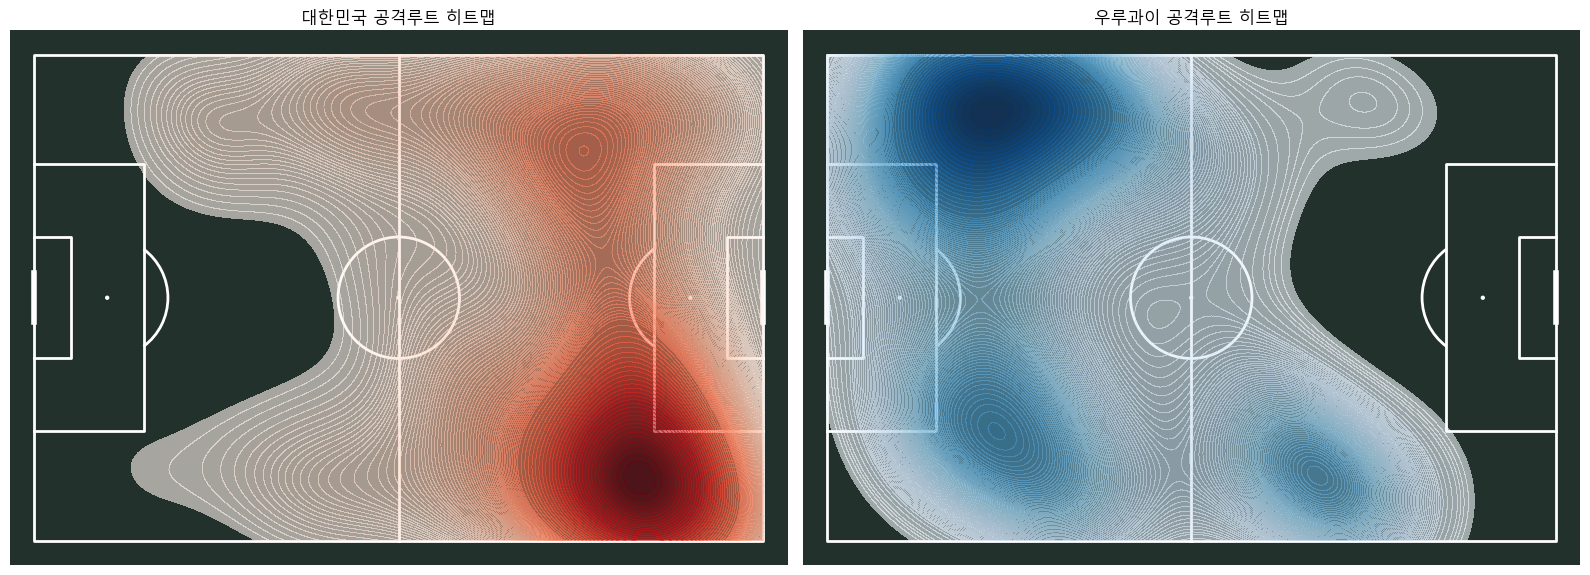

In [14]:
pitch = Pitch(pitch_type='statsbomb' , pitch_color='#22312b', line_color='white')

fig, (ax1, ax2) = pitch.draw(nrows=1, ncols=2, figsize=(16,8))
ax1.set_title('대한민국 공격루트 히트맵')
ax2.set_title('우루과이 공격루트 히트맵')

kor_roots_events = df_kor_event[
    df_kor_event['player_name'].isin(['Sang-Ho Na', 'Heung-Min Son', 'Ui-Jo Hwang'])
].dropna(subset=['x','y'])

ur_roots_events = df_ur_event[
    df_ur_event['player_name'].isin(['Darwin Gabriel Núñez Ribeiro', 'Luis Alberto Suárez Díaz','Facundo Pellistri Rebollo'])
].dropna(subset=['x','y'])

pitch.kdeplot(
    kor_roots_events['x'],
    kor_roots_events['y'],
    ax=ax1,
    fill=True,
    levels=100,
    cmap='Reds',
    alpha=0.6
)

pitch.kdeplot(
    120-ur_roots_events['x'],
    80-ur_roots_events['y'],
    ax=ax2,
    fill=True,
    levels=100,
    cmap='Blues',
    alpha=0.6
)

In [15]:
# 황인범 패스 데이터
inbeom_passes = df_kor_event[(df_kor_event['player_name'] == 'In-Beom Hwang') & (df_kor_event['type_name'] == 'Pass')]

# 정우영 패스 데이터
wooyoung_passes = df_kor_event[(df_kor_event['player_name'] == 'Woo-Young Jung') & (df_kor_event['type_name'] == 'Pass')]

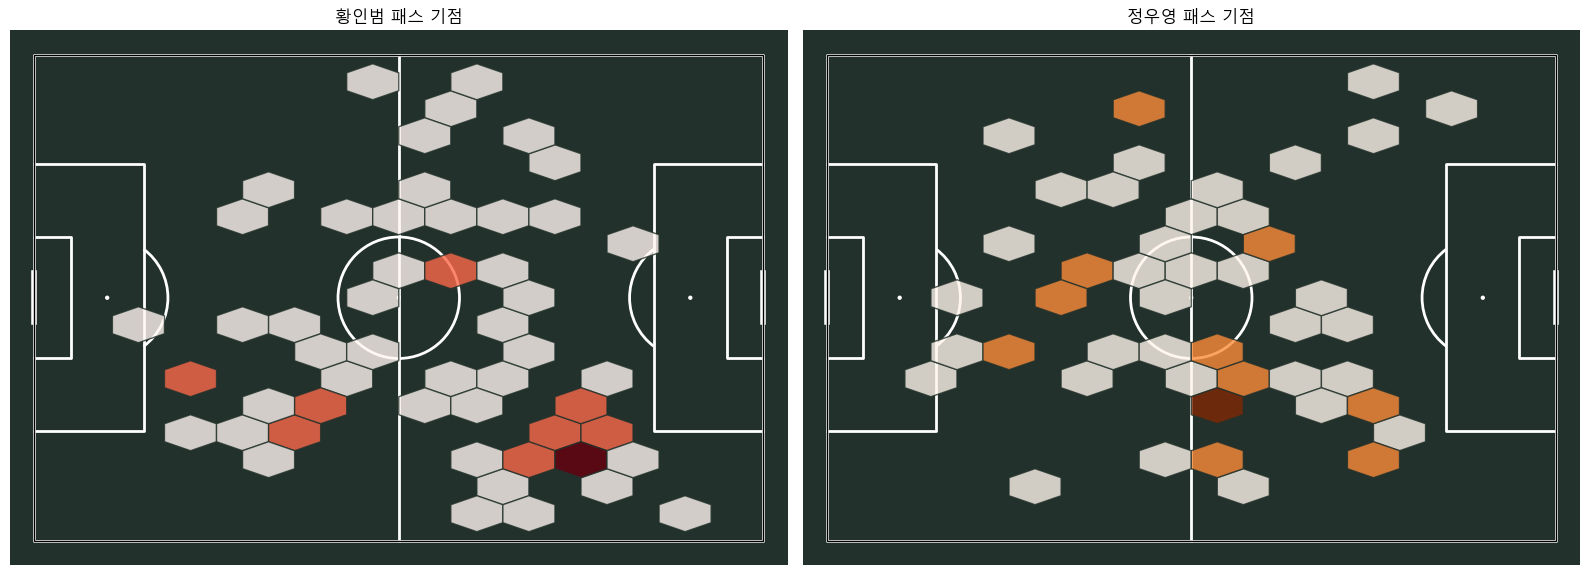

In [16]:
pitch = Pitch(pitch_type='statsbomb' , pitch_color='#22312b', line_color='white')
fig, (ax1, ax2) = pitch.draw(nrows=1, ncols=2, figsize=(16,8))
ax1.set_title('황인범 패스 기점')
ax2.set_title('정우영 패스 기점')
# 황인범 hexbin 
pitch.hexbin(
    inbeom_passes['x'],
    inbeom_passes['y'],
    ax=ax1,
    gridsize=(14,9), # 경기장을 가로 15개, 세로 10개의 육각형 격자 (숫자가 클수록 더 세밀한 구조)
    cmap='Reds',
    edgecolors='#22312b', # 육각형 테두리 색상 (경기장 바탕색과 맞춤)
    alpha = 0.8,
    mincnt = 1    # 이벤트가 1개 이상 발생한 격자만 표시
)
# 정우영 hexbin
pitch.hexbin(
    wooyoung_passes['x'],
    wooyoung_passes['y'],
    ax=ax2,
    gridsize=(14,9), 
    cmap='Oranges',
    edgecolors='#22312b', 
    alpha = 0.8,
    mincnt = 1    
)


In [17]:
# 벤탕쿠르 패스 데이터
ben_passes = df_ur_event[(df_ur_event['player_name'] == 'Rodrigo Bentancur Colmán') & (df_ur_event['type_name'] == 'Pass')]

# 발베르데 패스 데이터
val_passes = df_ur_event[(df_ur_event['player_name'] == 'Federico Santiago Valverde Dipetta') & (df_ur_event['type_name'] == 'Pass')]

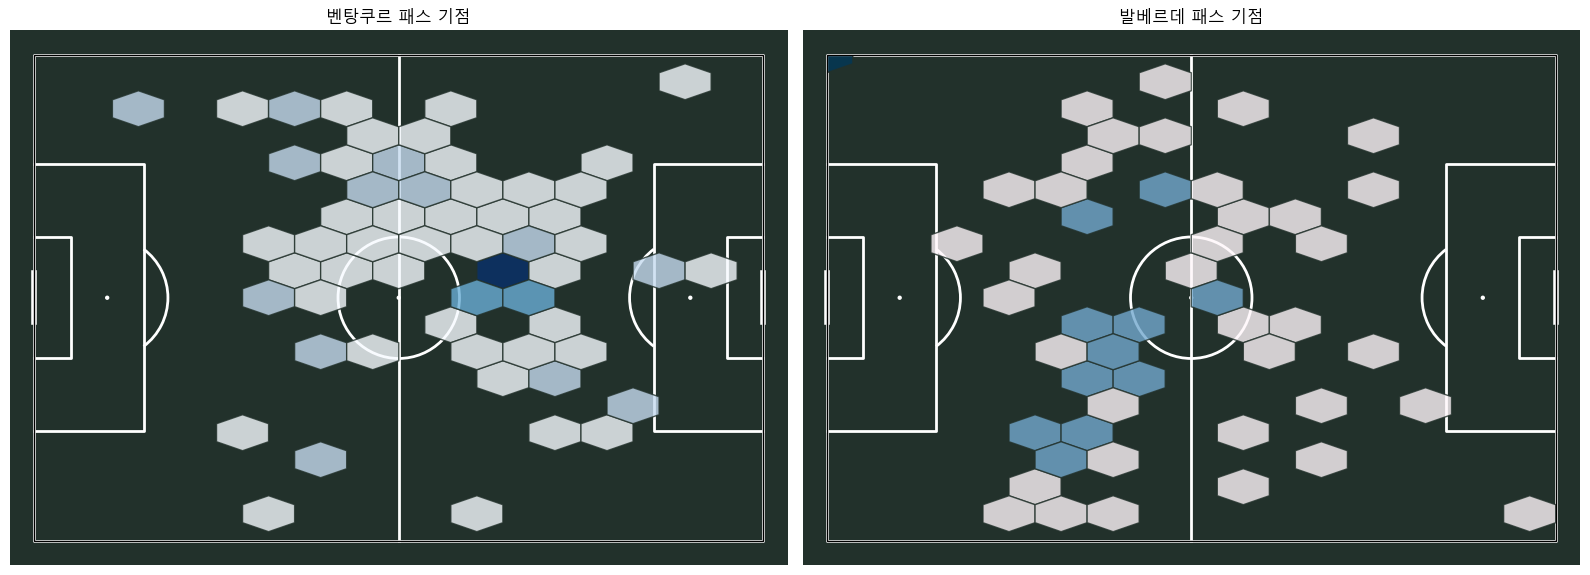

In [18]:
pitch=Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='white')
fig, (ax1,ax2) = pitch.draw(nrows=1, ncols=2, figsize=(16,8))

# 오른쪽에서 왼쪽으로 공격하는 기준
ax1.set_title('벤탕쿠르 패스 기점')
ax2.set_title('발베르데 패스 기점')

# 벤탕쿠르 hexbin
pitch.hexbin(
    120-ben_passes['x'],
    80-ben_passes['y'],
    ax=ax1,
    gridsize=(14,9),
    cmap='Blues',
    edgecolor='#22312b',
    alpha=0.8,
    mincnt=1
)
# 발베르데 hexbin
pitch.hexbin(
    120-val_passes['x'],
    80-val_passes['y'],
    ax=ax2,
    gridsize=(14,9),
    cmap='PuBu',
    edgecolor='#22312b',
    alpha=0.8,
    mincnt=1
)

In [19]:
# 대한민국 패스 데이터
kor_mid_passes = df_kor_event[(df_kor_event['player_name'].isin(['In-Beom Hwang','Woo-Young Jung'])) & (df_kor_event['type_name'] == 'Pass')]

# 우루과이 패스 데이터
ur_mid_passes = df_ur_event[(df_ur_event['player_name'].isin(['Rodrigo Bentancur Colmán','Federico Santiago Valverde Dipetta'])) & (df_ur_event['type_name'] == 'Pass')]

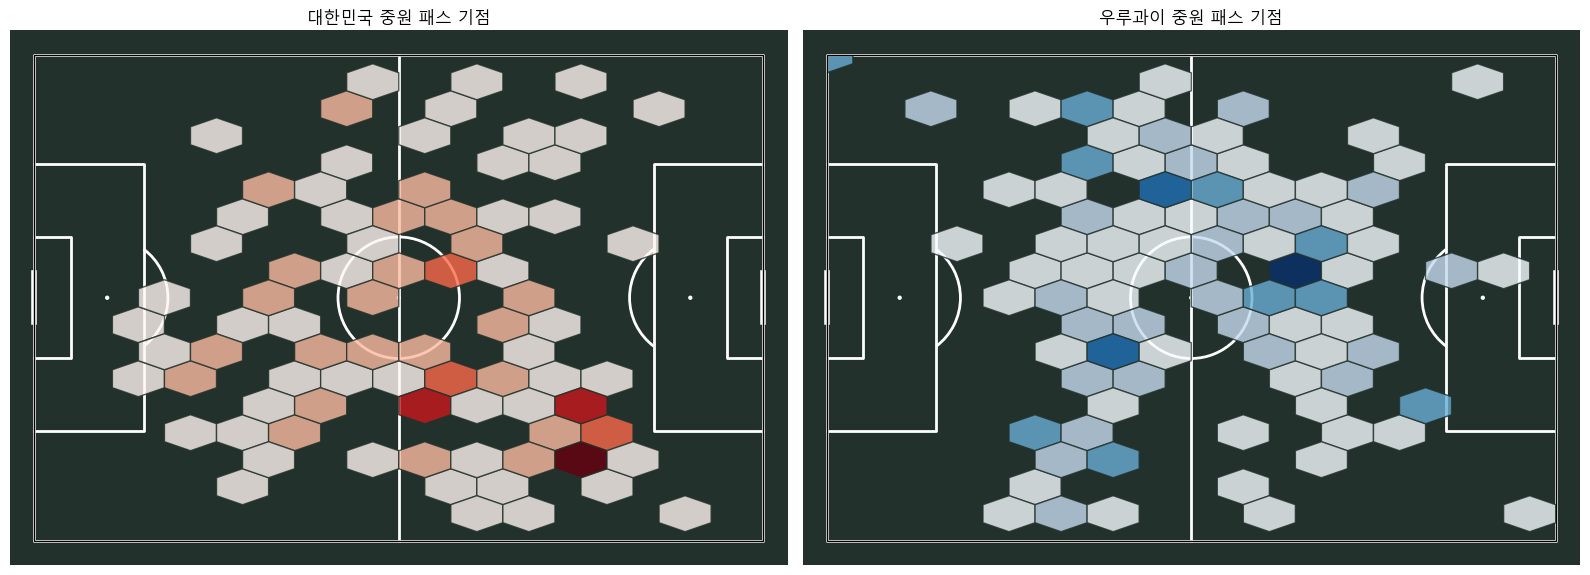

In [20]:
pitch=Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='white')
fig,(ax1,ax2) = pitch.draw(nrows=1, ncols=2, figsize=(16,8))

ax1.set_title('대한민국 중원 패스 기점')
ax2.set_title('우루과이 중원 패스 기점')

pitch.hexbin(
    kor_mid_passes['x'],
    kor_mid_passes['y'],
    ax=ax1,
    gridsize=(14,9),
    cmap='Reds',
    edgecolor='#22312b',
    alpha=0.8,
    mincnt=1
)

pitch.hexbin(
    120-ur_mid_passes['x'],
    80-ur_mid_passes['y'],
    ax=ax2,
    gridsize=(14,9),
    cmap='Blues',
    edgecolor='#22312b',
    alpha=0.8,
    mincnt=1
)

In [21]:
# 패스 조건 분류 함수
def classify_passes(df_event, player_name):
    # 해당 선수의 성공한 패스 추출
    passes = df_event[
        (df_event['player_name'] == player_name) &
        (df_event['type_name'] == 'Pass') &
        (df_event['outcome_name'].isna()) #성공 패스
    ].dropna(subset=['x','y','end_x','end_y']).copy()

    # 총 성공 패스 수
    total_passes = len(passes)

    # 조건 설정 
    cond1 = (passes['end_x'] - passes['x']) >= 10 # 전방 전진 패스 (10m+)
    cond2 = (passes['end_x'] >= 102) & (passes['end_y'] >= 18) & (passes['end_y'] <= 62) # 박스 투입

    # 3가지 조건 분류
    passes['pass_type'] = '기타 전방 패스'
    passes.loc[cond1 & ~cond2, 'pass_type'] = '전방 전진 패스(10m+)'
    passes.loc[~cond1 & cond2, 'pass_type'] = '박스 안 투입 패스'
    passes.loc[cond1 & cond2, 'pass_type'] = '두 조건 모두 만족'
    
    # 조건에 해당하는 패스만 필터링
    filtered_passes = passes[cond1 | cond2].copy()

    # 조건별 횟수 집계
    c1_cnt = (cond1 & ~cond2).sum()
    c2_cnt = (~cond1 & cond2).sum()
    c3_cnt = (cond1 & cond2).sum()

    return filtered_passes, [c1_cnt, c2_cnt, c3_cnt], total_passes


In [22]:
# 대한민국 
# 데이터 가공
df_inbeom_p, inbeom_counts, inbeom_total = classify_passes(df_event, 'In-Beom Hwang')
df_wooyoung_p, wooyoung_counts, wooyoung_total = classify_passes(df_event, 'Woo-Young Jung')

# 우루과이
# 데이터 가공
df_val_p, val_counts, val_total = classify_passes(df_event, 'Federico Santiago Valverde Dipetta')
df_ben_p, ben_counts, ben_total = classify_passes(df_event, 'Rodrigo Bentancur Colmán')

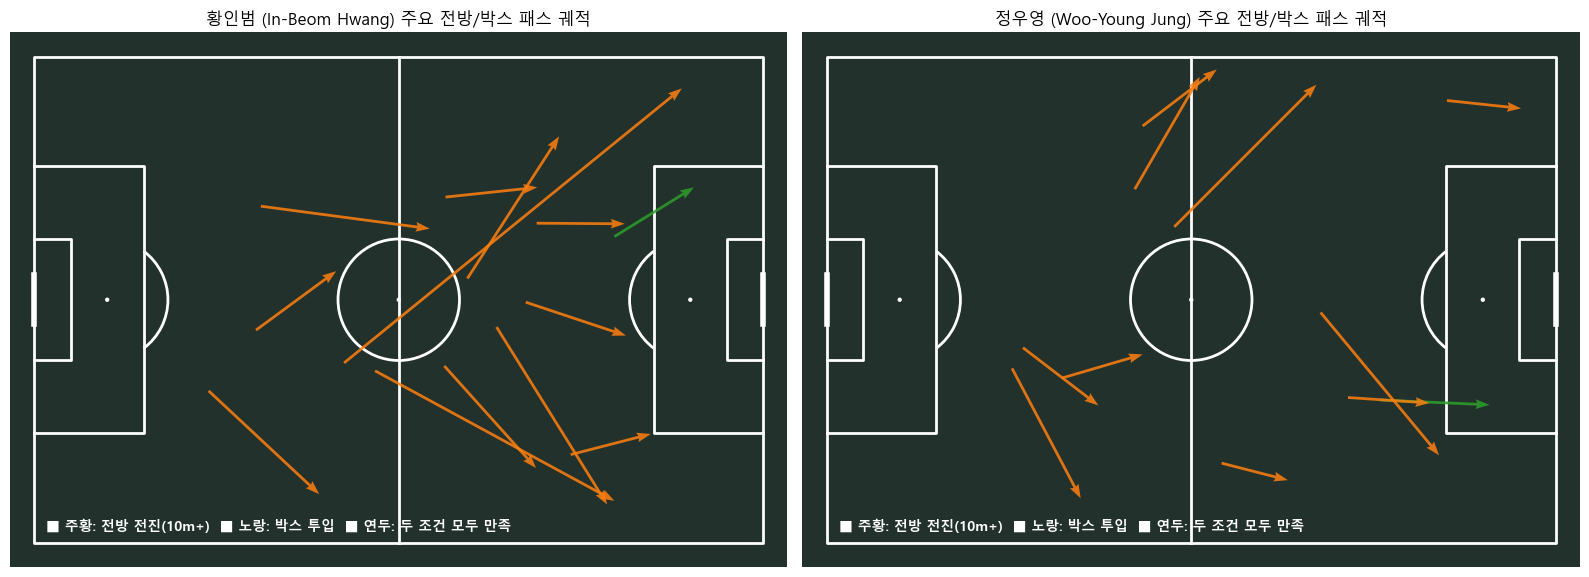

In [23]:
# 패스 방향 분석 (arrows map)
pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='white')
fig, (ax1, ax2) = pitch.draw(nrows=1, ncols=2, figsize=(16,8))

ax1.set_title('황인범 (In-Beom Hwang) 주요 전방/박스 패스 궤적')
ax2.set_title('정우영 (Woo-Young Jung) 주요 전방/박스 패스 궤적')

# 색상 매핑: 전진=주황, 박스=노랑, 둘 다 만족=연두
color_map = {
    '전방 전진 패스(10m+)' : '#ff7f0e',
    '박스 안 투입 패스' : '#e5de00',
    '두 조건 모두 만족' : '#2ca02c'
}

for df_p, ax in [(df_inbeom_p, ax1), (df_wooyoung_p, ax2)]:
    for _, p in df_p.iterrows():
        c = color_map.get(
            p['pass_type'],
            'white'
        )
        pitch.arrows(
            p['x'], 
            p['y'], 
            p['end_x'], 
            p['end_y'], 
            color=c, 
            alpha=0.85,
            width=2,
            headwidth=3.5,
            ax=ax
        )
ax1.text(2, 78, "■ 주황: 전방 전진(10m+)  ■ 노랑: 박스 투입  ■ 연두: 두 조건 모두 만족", color='white', fontsize=10, weight='bold')
ax2.text(2, 78, "■ 주황: 전방 전진(10m+)  ■ 노랑: 박스 투입  ■ 연두: 두 조건 모두 만족", color='white', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()        

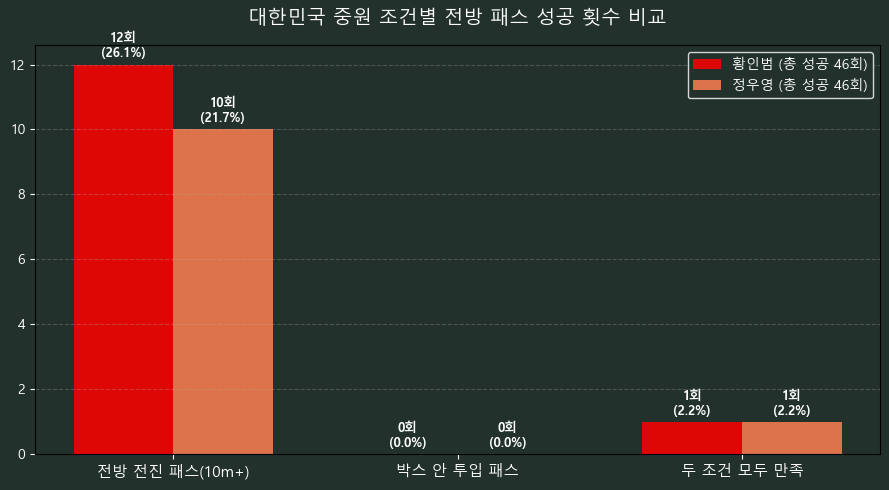

In [24]:
# 중원 조건별 패스 성공 횟수 bar chart
fig, ax = plt.subplots(figsize=(9, 5), facecolor='#22312b')
ax.set_facecolor('#22312b')

categories = ['전방 전진 패스(10m+)', '박스 안 투입 패스', '두 조건 모두 만족']
x = np.arange(len(categories))
width = 0.35

rects1 = ax.bar(x - width/2, inbeom_counts, width, label=f'황인범 (총 성공 {inbeom_total}회)', color='red', alpha=0.85)
rects2 = ax.bar(x + width/2, wooyoung_counts, width, label=f'정우영 (총 성공 {wooyoung_total}회)', color='#FF7F50', alpha=0.85)

ax.set_title("대한민국 중원 조건별 전방 패스 성공 횟수 비교", color='white', fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(categories, color='white', fontsize=11)
ax.tick_params(colors='white')
ax.legend(facecolor='#22312b', edgecolor='white', labelcolor='white')
ax.grid(axis='y', linestyle='--', alpha=0.3)

# 막대 위 숫자 및 비율(%) 표기
for rects, total in [(rects1, inbeom_total), (rects2, wooyoung_total)]:
    for rect in rects:
        height = rect.get_height()
        pct = (height / total * 100) if total > 0 else 0
        ax.annotate(f'{int(height)}회\n({pct:.1f}%)',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', color='white', fontsize=9, weight='bold')

plt.tight_layout()
plt.show()

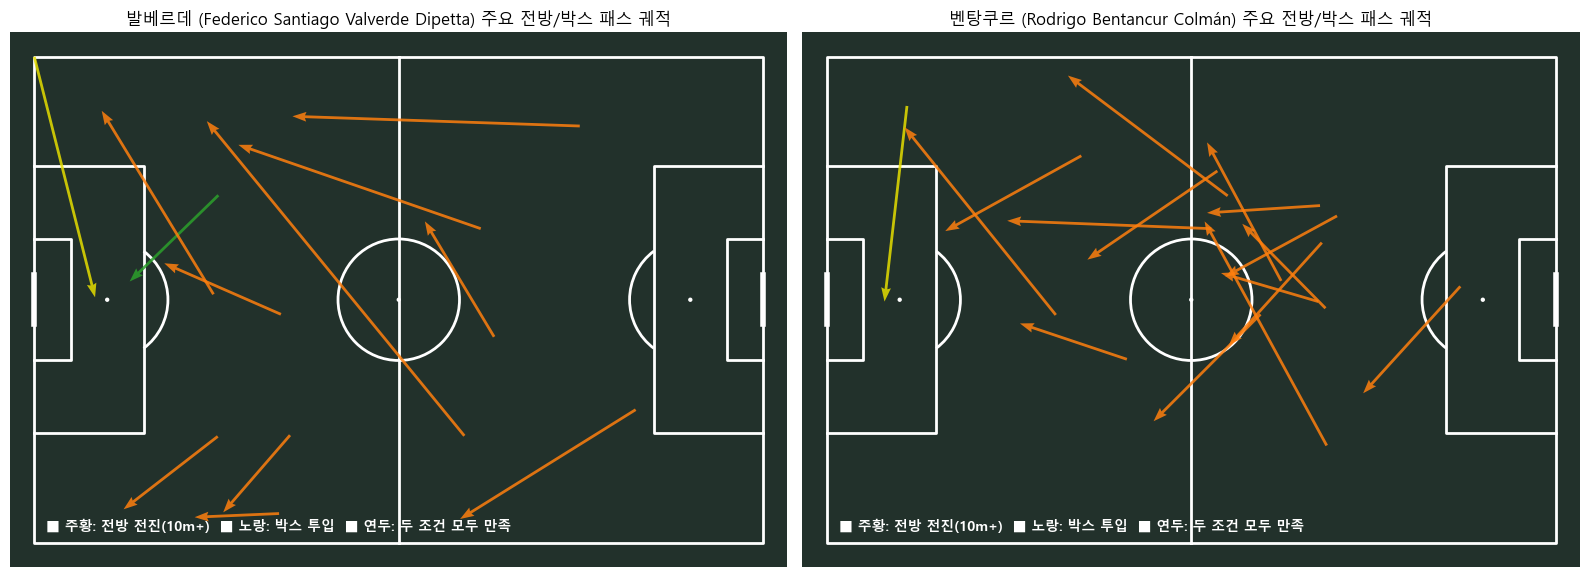

In [25]:
# 패스 방향 분석 (arrows map)
pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='white')
fig, (ax1, ax2) = pitch.draw(nrows=1, ncols=2, figsize=(16,8))

ax1.set_title('발베르데 (Federico Santiago Valverde Dipetta) 주요 전방/박스 패스 궤적')
ax2.set_title('벤탕쿠르 (Rodrigo Bentancur Colmán) 주요 전방/박스 패스 궤적')

# 색상 매핑: 전진=주황, 박스=노랑, 둘 다 만족=연두
color_map = {
    '전방 전진 패스(10m+)' : '#ff7f0e',
    '박스 안 투입 패스' : '#e5de00',
    '두 조건 모두 만족' : '#2ca02c'
}

for df_p, ax in [(df_val_p, ax1), (df_ben_p, ax2)]:
    for _, p in df_p.iterrows():
        c = color_map.get(
            p['pass_type'],
            'white'
        )
        pitch.arrows(
            120-p['x'], 
            80-p['y'], 
            120-p['end_x'], 
            80-p['end_y'], 
            color=c, 
            alpha=0.85,
            width=2,
            headwidth=3.5,
            ax=ax
        )
ax1.text(2, 78, "■ 주황: 전방 전진(10m+)  ■ 노랑: 박스 투입  ■ 연두: 두 조건 모두 만족", color='white', fontsize=10, weight='bold')
ax2.text(2, 78, "■ 주황: 전방 전진(10m+)  ■ 노랑: 박스 투입  ■ 연두: 두 조건 모두 만족", color='white', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()        

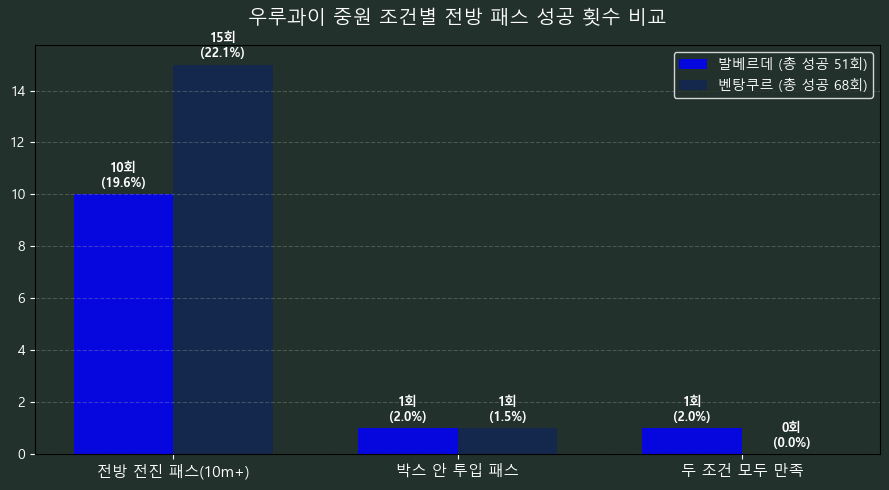

In [26]:
# 중원 조건별 패스 성공 횟수 bar chart
fig, ax = plt.subplots(figsize=(9, 5), facecolor='#22312b')
ax.set_facecolor('#22312b')

categories = ['전방 전진 패스(10m+)', '박스 안 투입 패스', '두 조건 모두 만족']
x = np.arange(len(categories))
width = 0.35

rects1 = ax.bar(x - width/2, val_counts, width, label=f'발베르데 (총 성공 {val_total}회)', color='blue', alpha=0.85)
rects2 = ax.bar(x + width/2, ben_counts, width, label=f'벤탕쿠르 (총 성공 {ben_total}회)', color='#112752', alpha=0.85)

ax.set_title("우루과이 중원 조건별 전방 패스 성공 횟수 비교", color='white', fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(categories, color='white', fontsize=11)
ax.tick_params(colors='white')
ax.legend(facecolor='#22312b', edgecolor='white', labelcolor='white')
ax.grid(axis='y', linestyle='--', alpha=0.3)

# 막대 위 숫자 및 비율(%) 표기
for rects, total in [(rects1, val_total), (rects2, ben_total)]:
    for rect in rects:
        height = rect.get_height()
        pct = (height / total * 100) if total > 0 else 0
        ax.annotate(f'{int(height)}회\n({pct:.1f}%)',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', color='white', fontsize=9, weight='bold')

plt.tight_layout()
plt.show()

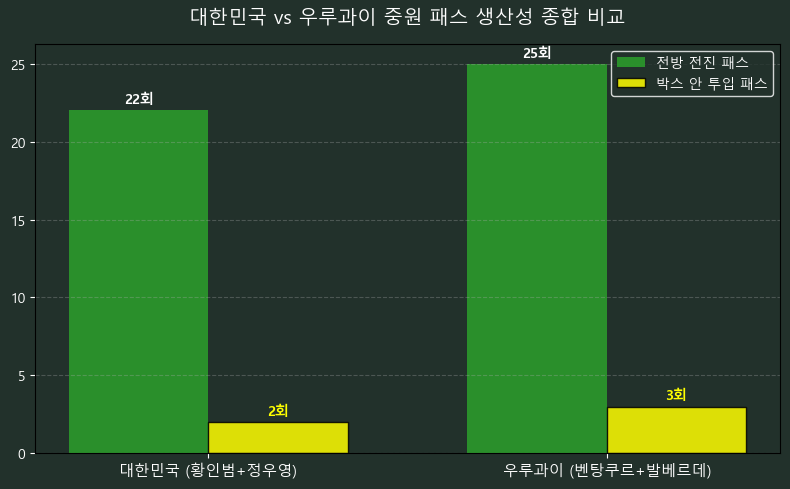

In [27]:
# 양 팀 미드필더 합산 데이터
kor_mid_prog_total = inbeom_counts[0] + wooyoung_counts[0] # 전방 전진 패스
kor_mid_box_total = (inbeom_counts[1] + inbeom_counts[2]) + (wooyoung_counts[1] + wooyoung_counts[2]) # 박스 투입 포함 전체 패스

ur_mid_prog_total = val_counts[0] + ben_counts[0]
ur_mid_box_total = (val_counts[1] + val_counts[2]) + (ben_counts[1] + ben_counts[2])

# 종합 막대그래프 시각화

fig, ax = plt.subplots(figsize=(8, 5), facecolor='#22312b')
ax.set_facecolor('#22312b')

teams = ['대한민국 (황인범+정우영)', '우루과이 (벤탕쿠르+발베르데)']
x = np.arange(len(teams))
width = 0.35

rects1 = ax.bar(x - width/2, [kor_mid_prog_total, ur_mid_prog_total], width, label='전방 전진 패스', color='#2ca02c', alpha=0.85)
rects2 = ax.bar(x + width/2, [kor_mid_box_total, ur_mid_box_total], width, label='박스 안 투입 패스', color='yellow', alpha=0.85, edgecolor='black')

ax.set_title("대한민국 vs 우루과이 중원 패스 생산성 종합 비교", color='white', fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(teams, color='white', fontsize=11)
ax.tick_params(colors='white')
ax.legend(facecolor='#22312b', edgecolor='white', labelcolor='white')
ax.grid(axis='y', linestyle='--', alpha=0.3)

for rect in rects1:
    h = rect.get_height()
    ax.annotate(f'{int(h)}회', xy=(rect.get_x() + rect.get_width()/2, h), xytext=(0, 3),
                textcoords="offset points", ha='center', va='bottom', color='white', weight='bold')

for rect in rects2:
    h = rect.get_height()
    ax.annotate(f'{int(h)}회', xy=(rect.get_x() + rect.get_width()/2, h), xytext=(0, 3),
                textcoords="offset points", ha='center', va='bottom', color='yellow', weight='bold')

plt.tight_layout()
plt.show()

In [29]:
# 양 팀 슈팅 데이터 준비
kor_shots = df_event[(df_event['team_name'] == 'South Korea') & (df_event['type_name'] == 'Shot')].copy()
ur_shots = df_event[(df_event['team_name'] == 'Uruguay') & (df_event['type_name'] == 'Shot')].copy()

kor_total_xg = kor_shots['shot_statsbomb_xg'].sum()
ur_total_xg = ur_shots['shot_statsbomb_xg'].sum()

print(f"대한민국 슈팅 {len(kor_shots)}회 / 누적 xG {kor_total_xg:.2f}")
print(f"우루과이 슈팅 {len(ur_shots)}회 / 누적 xG {ur_total_xg:.2f}")

대한민국 슈팅 7회 / 누적 xG 0.49
우루과이 슈팅 10회 / 누적 xG 0.42


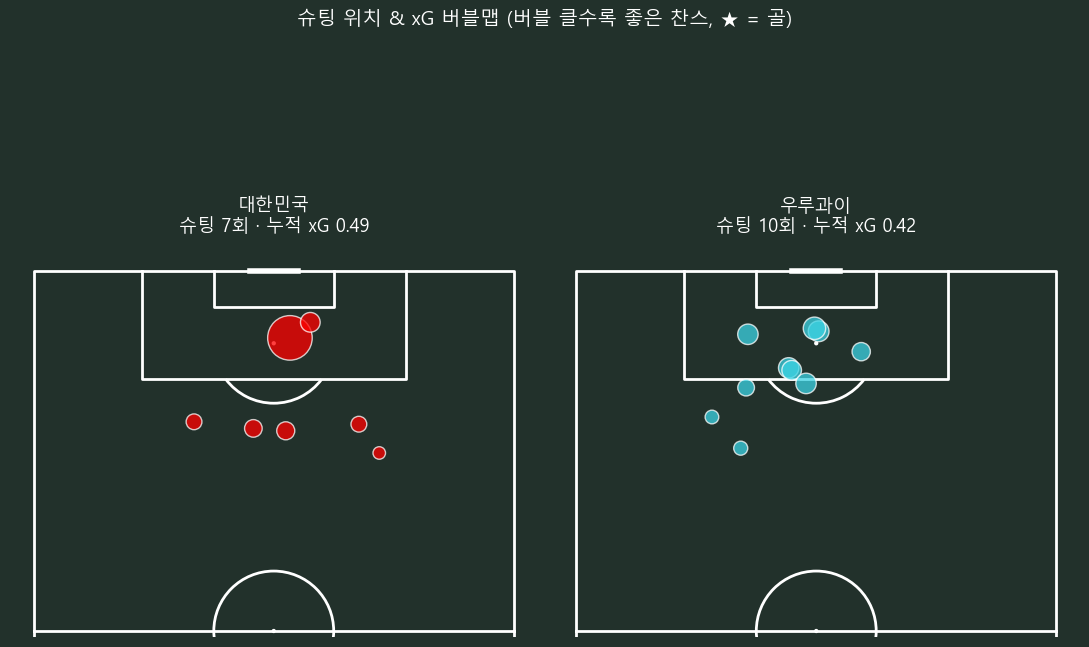

In [35]:
# 1) 양 팀 슈팅 위치 + xG 버블맵 (하프피치 2개: 왼쪽 대한민국 / 오른쪽 우루과이, 골대가 위쪽)
from mplsoccer import VerticalPitch

pitch = VerticalPitch(pitch_type='statsbomb', half=True, pitch_color='#22312b', line_color='white', pad_bottom=1)
fig, axes = pitch.draw(nrows=1, ncols=2, figsize=(11, 8))
ax1, ax2 = axes
fig.patch.set_facecolor('#22312b')

def goal_mask(df):
    return df['outcome_name'] == 'Goal'

# --- 대한민국 (왼쪽) ---
pitch.scatter(
    kor_shots['x'], kor_shots['y'],
    s=kor_shots['shot_statsbomb_xg'] * 3000 + 60,
    color='red', edgecolors='white', linewidth=1, alpha=0.75,
    ax=ax1, zorder=3
)
kor_goals = kor_shots[goal_mask(kor_shots)]
if len(kor_goals):
    pitch.scatter(kor_goals['x'], kor_goals['y'], s=400, marker='*', color='gold',
                  edgecolors='black', linewidth=1, ax=ax1, zorder=4)
ax1.set_title(f"대한민국\n슈팅 {len(kor_shots)}회 · 누적 xG {kor_total_xg:.2f}",
              color='white', fontsize=13, pad=12)

# --- 우루과이 (오른쪽) ---
pitch.scatter(
    ur_shots['x'], ur_shots['y'],
    s=ur_shots['shot_statsbomb_xg'] * 3000 + 60,
    color='#3cd4e5', edgecolors='white', linewidth=1, alpha=0.75,
    ax=ax2, zorder=3
)
ur_goals = ur_shots[goal_mask(ur_shots)]
if len(ur_goals):
    pitch.scatter(ur_goals['x'], ur_goals['y'], s=400, marker='*', color='gold',
                  edgecolors='black', linewidth=1, ax=ax2, zorder=4)
ax2.set_title(f"우루과이\n슈팅 {len(ur_shots)}회 · 누적 xG {ur_total_xg:.2f}",
              color='white', fontsize=13, pad=12)

fig.suptitle('슈팅 위치 & xG 버블맵 (버블 클수록 좋은 찬스, ★ = 골)', color='white', fontsize=14, y=1.02)

plt.tight_layout()
plt.show()


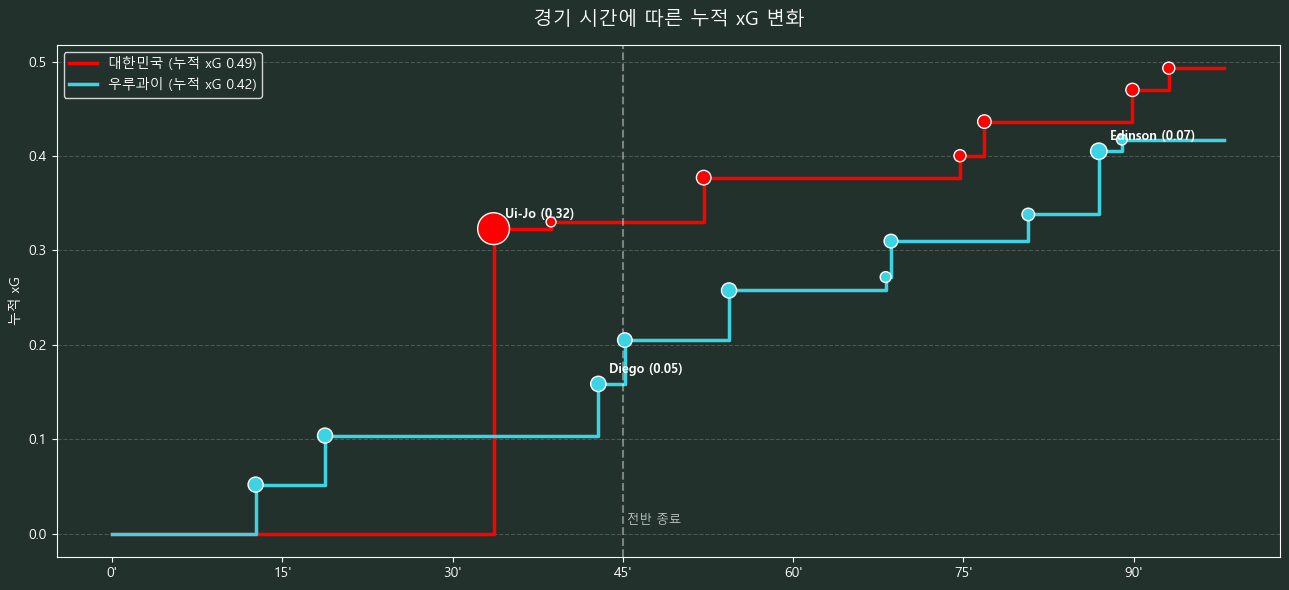

In [31]:
# 2) 슈팅별 xG 누적 타임라인 - 경기 흐름상 어느 팀이 더 좋은 기회를 만들었는지
kor_t = kor_shots.copy()
ur_t = ur_shots.copy()
kor_t['time_sec'] = kor_t['minute'] * 60 + kor_t['second']
ur_t['time_sec'] = ur_t['minute'] * 60 + ur_t['second']
kor_t = kor_t.sort_values('time_sec')
ur_t = ur_t.sort_values('time_sec')
kor_t['cum_xg'] = kor_t['shot_statsbomb_xg'].cumsum()
ur_t['cum_xg'] = ur_t['shot_statsbomb_xg'].cumsum()

# 경기 종료 시점까지 계단식 라인을 이어주기 위한 끝점 보정
match_end_sec = int(df_event['minute'].max()) * 60 + 60
halftime_sec = 45 * 60

fig, ax = plt.subplots(figsize=(13, 6), facecolor='#22312b')
ax.set_facecolor('#22312b')

# 계단식(step) 라인: 슈팅이 나올 때마다 xG가 누적되어 계단처럼 상승
ax.step(
    [0] + kor_t['time_sec'].tolist() + [match_end_sec],
    [0] + kor_t['cum_xg'].tolist() + [kor_t['cum_xg'].iloc[-1] if len(kor_t) else 0],
    where='post', color='red', linewidth=2.5, label=f'대한민국 (누적 xG {kor_total_xg:.2f})'
)
ax.step(
    [0] + ur_t['time_sec'].tolist() + [match_end_sec],
    [0] + ur_t['cum_xg'].tolist() + [ur_t['cum_xg'].iloc[-1] if len(ur_t) else 0],
    where='post', color='#3cd4e5', linewidth=2.5, label=f'우루과이 (누적 xG {ur_total_xg:.2f})'
)

# 개별 슈팅 지점 마커 (마커 크기 = 해당 슈팅의 xG)
ax.scatter(kor_t['time_sec'], kor_t['cum_xg'], s=kor_t['shot_statsbomb_xg'] * 1500 + 40,
           color='red', edgecolor='white', zorder=3)
ax.scatter(ur_t['time_sec'], ur_t['cum_xg'], s=ur_t['shot_statsbomb_xg'] * 1500 + 40,
           color='#3cd4e5', edgecolor='white', zorder=3)

# 가장 위협적이었던 찬스(xG 상위)에 선수 이름 라벨링
top_chances = pd.concat([kor_t, ur_t]).nlargest(3, 'shot_statsbomb_xg')
for _, row in top_chances.iterrows():
    ax.annotate(
        f"{row['player_name'].split()[0]} ({row['shot_statsbomb_xg']:.2f})",
        xy=(row['time_sec'], row['cum_xg']),
        xytext=(8, 8), textcoords='offset points',
        color='white', fontsize=9, weight='bold'
    )

ax.axvline(halftime_sec, color='white', linestyle='--', alpha=0.4)
ax.text(halftime_sec + 20, ax.get_ylim()[1] * 0.02, '전반 종료', color='white', fontsize=9, alpha=0.7)

xticks = list(range(0, match_end_sec + 1, 15 * 60))
ax.set_xticks(xticks)
ax.set_xticklabels([f'{t//60}\'' for t in xticks], color='white')
ax.set_ylabel('누적 xG', color='white')
ax.tick_params(colors='white')
ax.set_title('경기 시간에 따른 누적 xG 변화', color='white', fontsize=14, pad=15)
ax.legend(facecolor='#22312b', edgecolor='white', labelcolor='white', loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.3)
for spine in ax.spines.values():
    spine.set_color('white')

plt.tight_layout()
plt.show()

In [32]:
# 나상호 선수의 시간순 터치 포인트 구성
import matplotlib.animation as animation

na_events = df_event[df_event['player_name'] == 'Sang-Ho Na'].sort_values(['minute', 'second']).copy()

path_points = []  # (time_sec, x, y, event_label)
for _, r in na_events.iterrows():
    t = r['minute'] * 60 + r['second']
    if pd.notna(r['x']) and pd.notna(r['y']):
        path_points.append((t, r['x'], r['y'], r['type_name']))
    # Carry 이벤트는 시작->끝 지점 사이를 실제로 드리블해서 이동한 구간이므로 끝점도 포함
    if r['type_name'] == 'Carry' and pd.notna(r['end_x']) and pd.notna(r['end_y']):
        path_points.append((t + 1, r['end_x'], r['end_y'], 'Carry_end'))

path_points.sort(key=lambda p: p[0])
print(f'총 {len(path_points)}개 포인트, {path_points[0][0]//60}분 ~ {path_points[-1][0]//60}분')


총 155개 포인트, 0분 ~ 72분


In [33]:
# 프레임 사이를 선형 보간해서 부드럽게 움직이도록 처리
INTERP_STEPS = 4  # 두 포인트 사이를 몇 프레임으로 나눌지

frames_xy = []
frames_time = []
for i in range(len(path_points) - 1):
    t0, x0, y0, _ = path_points[i]
    t1, x1, y1, _ = path_points[i + 1]
    for s in range(INTERP_STEPS):
        frac = s / INTERP_STEPS
        frames_xy.append((x0 + (x1 - x0) * frac, y0 + (y1 - y0) * frac))
        frames_time.append(t0 + (t1 - t0) * frac)
frames_xy.append((path_points[-1][1], path_points[-1][2]))
frames_time.append(path_points[-1][0])

print(f'총 프레임 수: {len(frames_xy)}')

총 프레임 수: 617


In [34]:
# 애니메이션 생성 및 GIF로 저장
pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='white')
fig, ax = pitch.draw(figsize=(10, 7))

fig.patch.set_facecolor('#22312b')
title_text = ax.text(60, 84, '', color='white', fontsize=13, weight='bold', ha='center')

# 궤적을 남기는 트레일 라인 (최근 이동 경로) + 현재 위치 마커
trail_line, = ax.plot([], [], color='#ffcc00', linewidth=2, alpha=0.6, zorder=2)
current_dot = ax.scatter([], [], s=250, color='red', edgecolors='white', linewidth=2, zorder=3)

TRAIL_LENGTH = 30  # 최근 몇 프레임까지 트레일로 표시할지

def init():
    trail_line.set_data([], [])
    current_dot.set_offsets(np.empty((0, 2)))
    title_text.set_text('')
    return trail_line, current_dot, title_text

def update(frame_idx):
    x, y = frames_xy[frame_idx]
    start = max(0, frame_idx - TRAIL_LENGTH)
    trail_x = [p[0] for p in frames_xy[start:frame_idx + 1]]
    trail_y = [p[1] for p in frames_xy[start:frame_idx + 1]]
    trail_line.set_data(trail_x, trail_y)
    current_dot.set_offsets([[x, y]])

    t = frames_time[frame_idx]
    minute, second = int(t // 60), int(t % 60)
    title_text.set_text(f"나상호 (Sang-Ho Na)  ·  {minute:02d}:{second:02d}")
    return trail_line, current_dot, title_text

anim = animation.FuncAnimation(
    fig, update, frames=len(frames_xy), init_func=init,
    interval=60, blit=True
)

# GIF로 저장 (Pillow 라이터 사용, ffmpeg 불필요)
gif_path = 'na_sangho_movement.gif'
anim.save(gif_path, writer=animation.PillowWriter(fps=18))
plt.close(fig)
print(f'저장 완료: {gif_path}')


저장 완료: na_sangho_movement.gif
